In [1]:
!pip install folium


Matplotlib created a temporary config/cache directory at /tmp/matplotlib-q5d9tgfr because the default path (/home/student/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


<IPython.core.display.Javascript object>


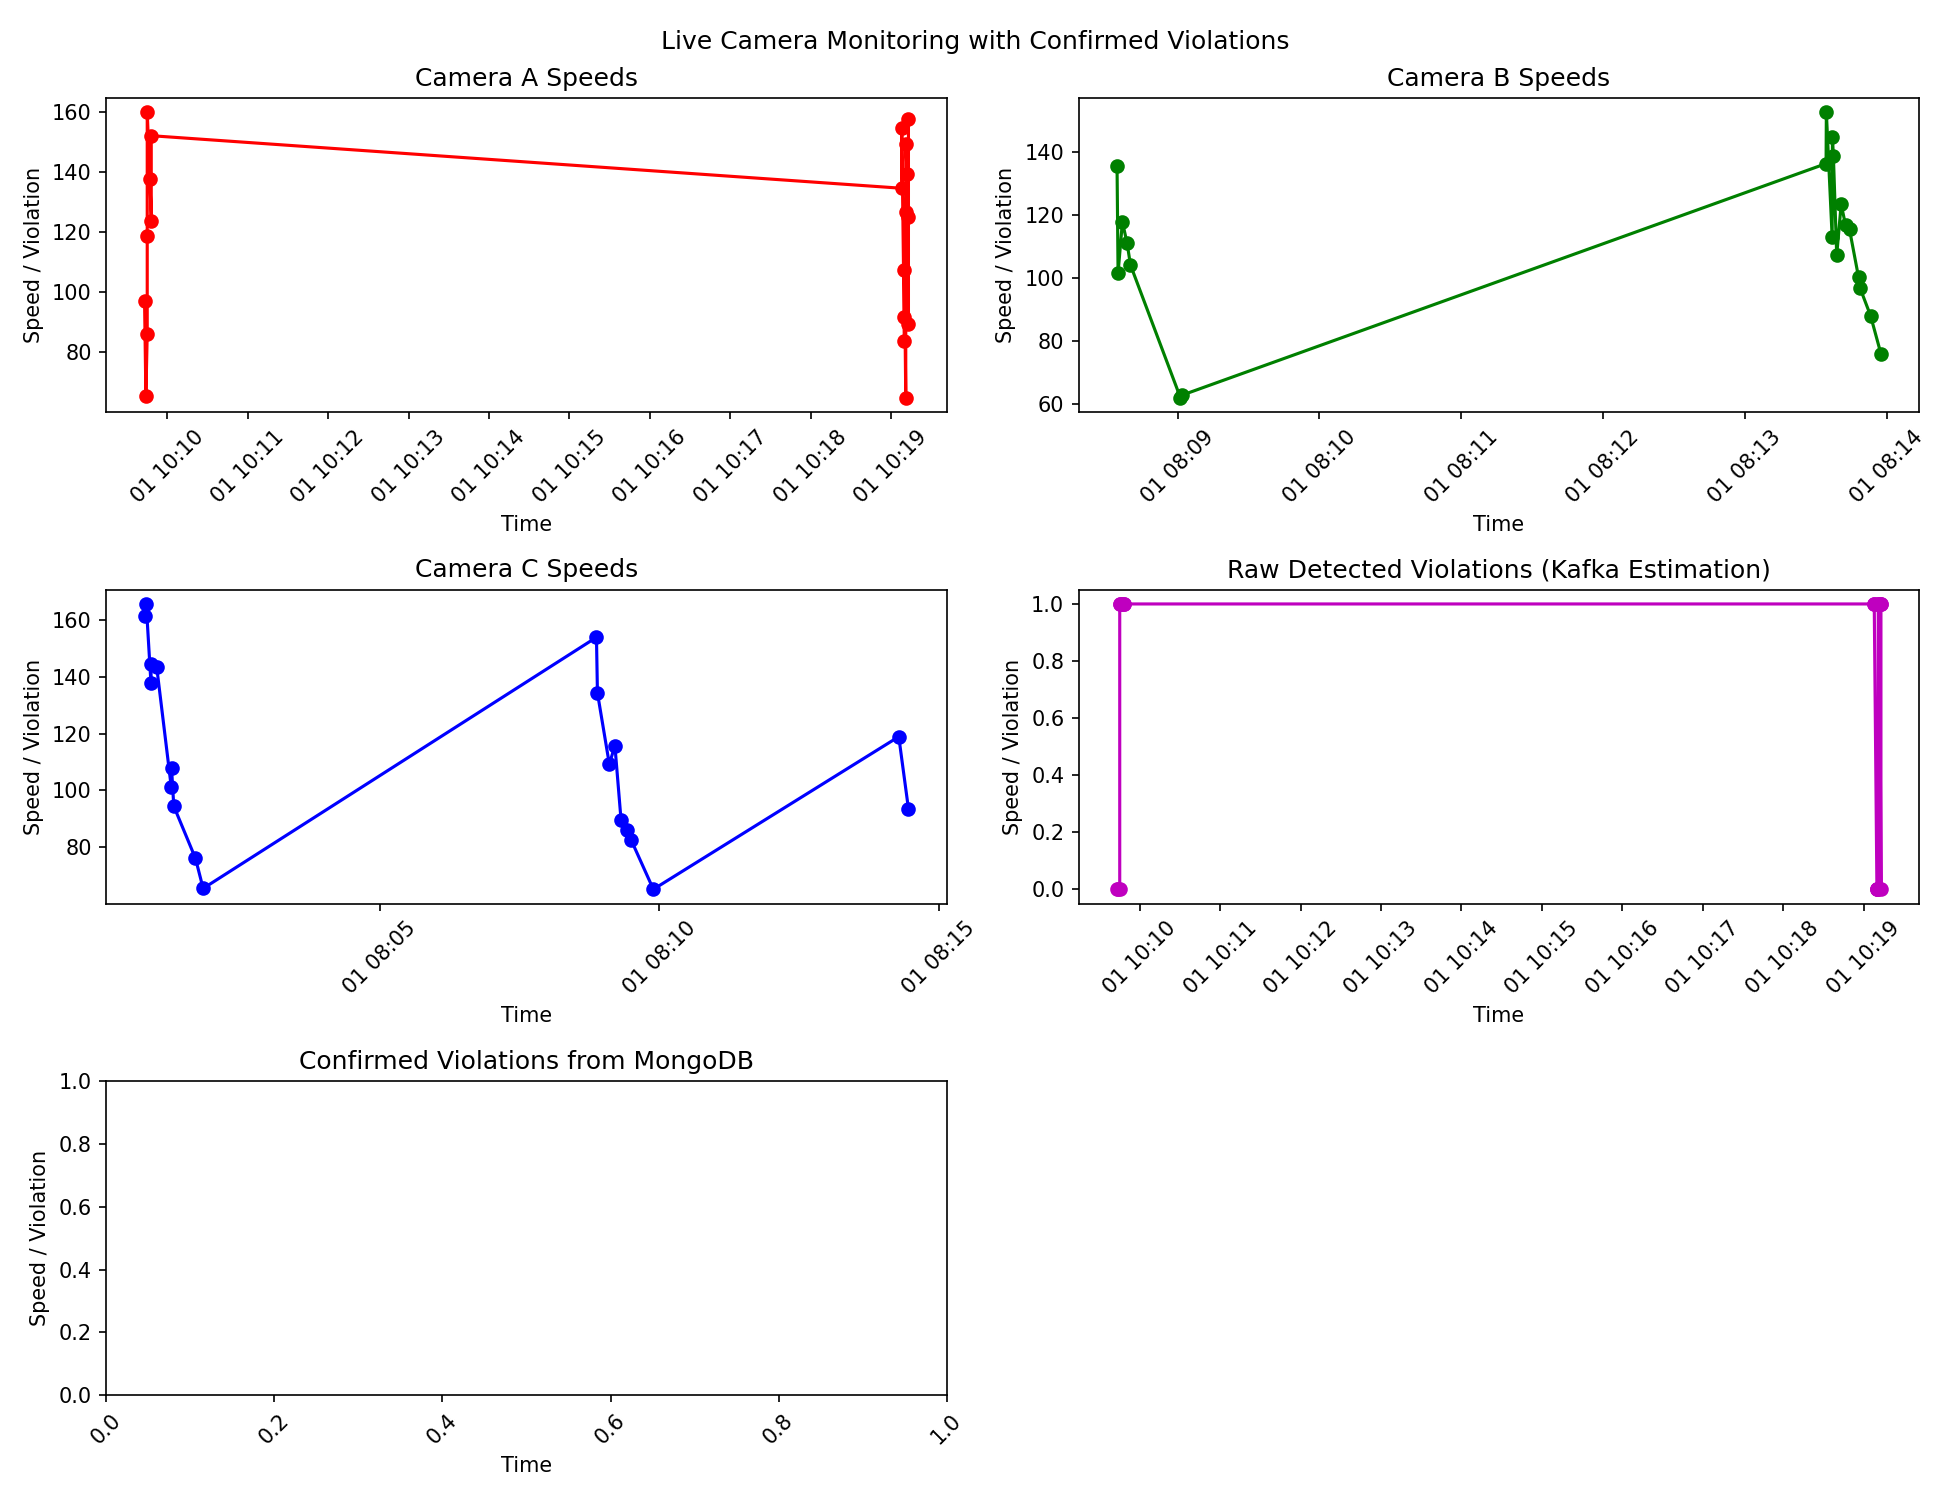

KeyboardInterrupt: 

In [2]:
from kafka3 import KafkaConsumer
from pymongo import MongoClient
import matplotlib.pyplot as plt
import datetime as dt
import json
import time

%matplotlib notebook

# Config
hostip = "host.docker.internal"
mongo_uri = "mongodb://host.docker.internal:27017"
db_name = "fit3182_db"
threshold = 110
max_len = 20
draw_interval = 2.0  # seconds

# Topics
topic_list = ['camera_event_a', 'camera_event_b', 'camera_event_c']

# Kafka consumer
consumer = KafkaConsumer(
    *topic_list,
    bootstrap_servers=[f"{hostip}:9092"],
    auto_offset_reset='earliest',
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    api_version=(0, 10)
)

# MongoDB client
mongo_client = MongoClient(mongo_uri)
db = mongo_client[db_name]
violation_coll = db["violations"]

# In-memory data storage
cam_a_x, cam_a_y = [], []
cam_b_x, cam_b_y = [], []
cam_c_x, cam_c_y = [], []
raw_violation_x, raw_violation_y = [], []
confirmed_violation_x, confirmed_violation_y = [], []

# Create plot
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
fig.suptitle("Live Camera Monitoring with Confirmed Violations")
ax1, ax2, ax3, ax4, ax5 = axes[0,0], axes[0,1], axes[1,0], axes[1,1], axes[2,0]
fig.delaxes(axes[2,1])  # Remove empty plot

def update_plots():
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.clear()

    ax1.set_title("Camera A Speeds")
    if cam_a_x:
        x, y = zip(*sorted(zip(cam_a_x, cam_a_y)))
        ax1.plot(x, y, 'r-o')

    ax2.set_title("Camera B Speeds")
    if cam_b_x:
        x, y = zip(*sorted(zip(cam_b_x, cam_b_y)))
        ax2.plot(x, y, 'g-o')

    ax3.set_title("Camera C Speeds")
    if cam_c_x:
        x, y = zip(*sorted(zip(cam_c_x, cam_c_y)))
        ax3.plot(x, y, 'b-o')

    ax4.set_title("Raw Detected Violations (Kafka Estimation)")
    if raw_violation_x:
        x, y = zip(*sorted(zip(raw_violation_x, raw_violation_y)))
        ax4.plot(x, y, 'm-o')

    ax5.set_title("Confirmed Violations from MongoDB")
    if confirmed_violation_x:
        x, y = zip(*sorted(zip(confirmed_violation_x, confirmed_violation_y)))
        ax5.plot(x, y, 'k-o')

    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.set_xlabel("Time")
        ax.set_ylabel("Speed / Violation")
        ax.tick_params(axis='x', rotation=45)

    fig.tight_layout()
    fig.canvas.draw()

def load_confirmed_violations():
    # Optional: filter for today's date
    records = violation_coll.find({}).sort("timestamp_end", -1).limit(20)
    x_vals, y_vals = [], []
    for rec in records:
        try:
            ts = rec.get("timestamp_end") or rec.get("timestamp_start")
            if isinstance(ts, str):
                ts = dt.datetime.fromisoformat(ts)
            x_vals.append(ts)
            y_vals.append(rec["max_speed"])
        except Exception as e:
            print("[MongoParseError]", e)
    return list(reversed(x_vals)), list(reversed(y_vals))

# Loop logic
last_draw_time = time.time()

for msg in consumer:
    data = msg.value
    try:
        # extract timestamp, speed, producer
        timestamp = dt.datetime.fromisoformat(data["timestamp"])
        speed = data["speed_reading"]
        producer = data["producer"]
        is_violation = int(speed > threshold)

        # Assign to correct camera
        if producer == "A":
            cam_a_x.append(timestamp)
            cam_a_y.append(speed)
        elif producer == "B":
            cam_b_x.append(timestamp)
            cam_b_y.append(speed)
        elif producer == "C":
            cam_c_x.append(timestamp)
            cam_c_y.append(speed)

        # Approximate violation (for visual comparison)
        raw_violation_x.append(timestamp)
        raw_violation_y.append(is_violation)

        # Append to in memory buffers
        # Trim to max_len
        for series in [
            cam_a_x, cam_a_y, cam_b_x, cam_b_y, cam_c_x, cam_c_y,
            raw_violation_x, raw_violation_y
        ]:
            while len(series) > max_len:
                series.pop(0)

        # Redraw periodically
        if time.time() - last_draw_time >= draw_interval:
            confirmed_violation_x, confirmed_violation_y = load_confirmed_violations()
            update_plots()
            last_draw_time = time.time()

        time.sleep(0.005)
    except Exception as e:
        print(f"[ParseError] {e} -- Raw: {msg.value}")
